## 🔍 AIC 2026 - Thử nghiệm Vector Search trực tiếp

Notebook này cho phép bạn gõ một câu query bằng văn bản, sau đó mã hoá thành vector (qua CLIP gốc) và truy vấn trực tiếp lên Qdrant Database. Kết quả được render dưới dạng bảng Markdown trực quan.

### Kết quả truy vấn từ Qdrant Cloud với Query = `Black and white surveillance CCTV camera footage showing a street robbery`:

| Rank | Score | Video ID | Frame ID | Thời điểm (s) | Clip ID | Ảnh Minh Hoạ |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **#01** | `0.3434` | L22_V031 | 22460 | 898.4s (14m 58s) | kf_556 | 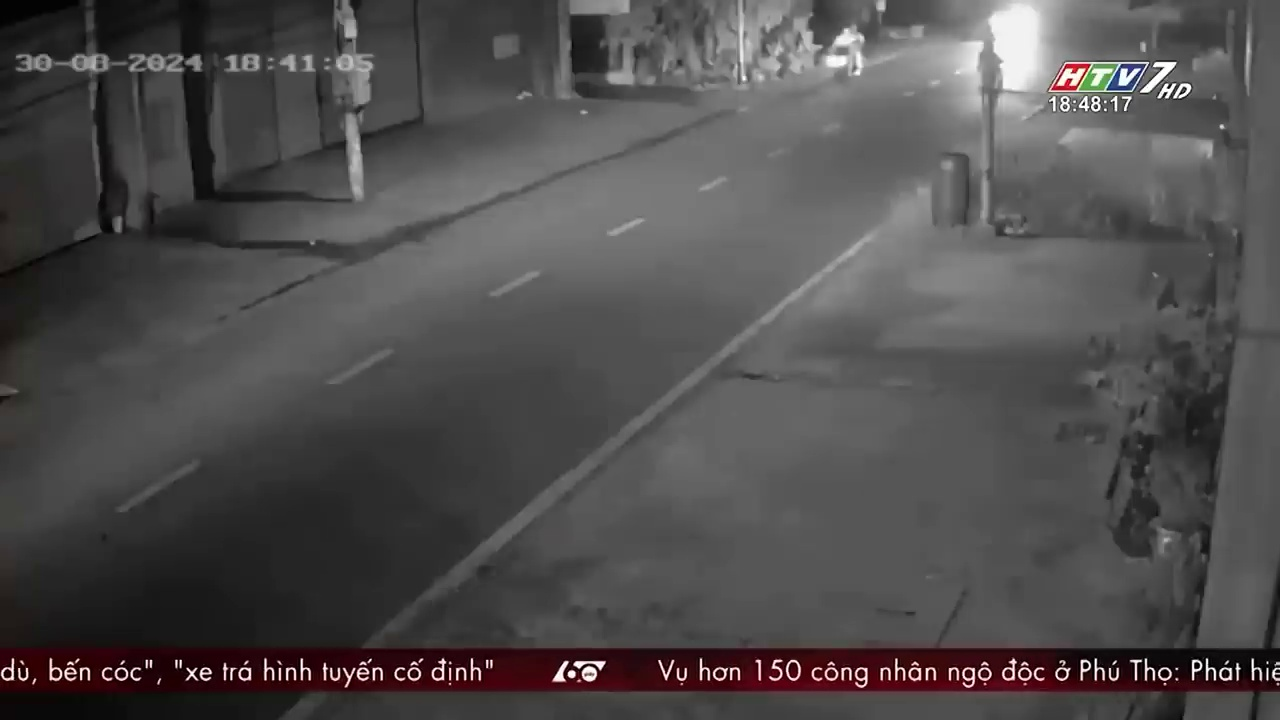 |
| **#02** | `0.3352` | L22_V031 | 22805 | 912.2s (15m 12s) | kf_562 | 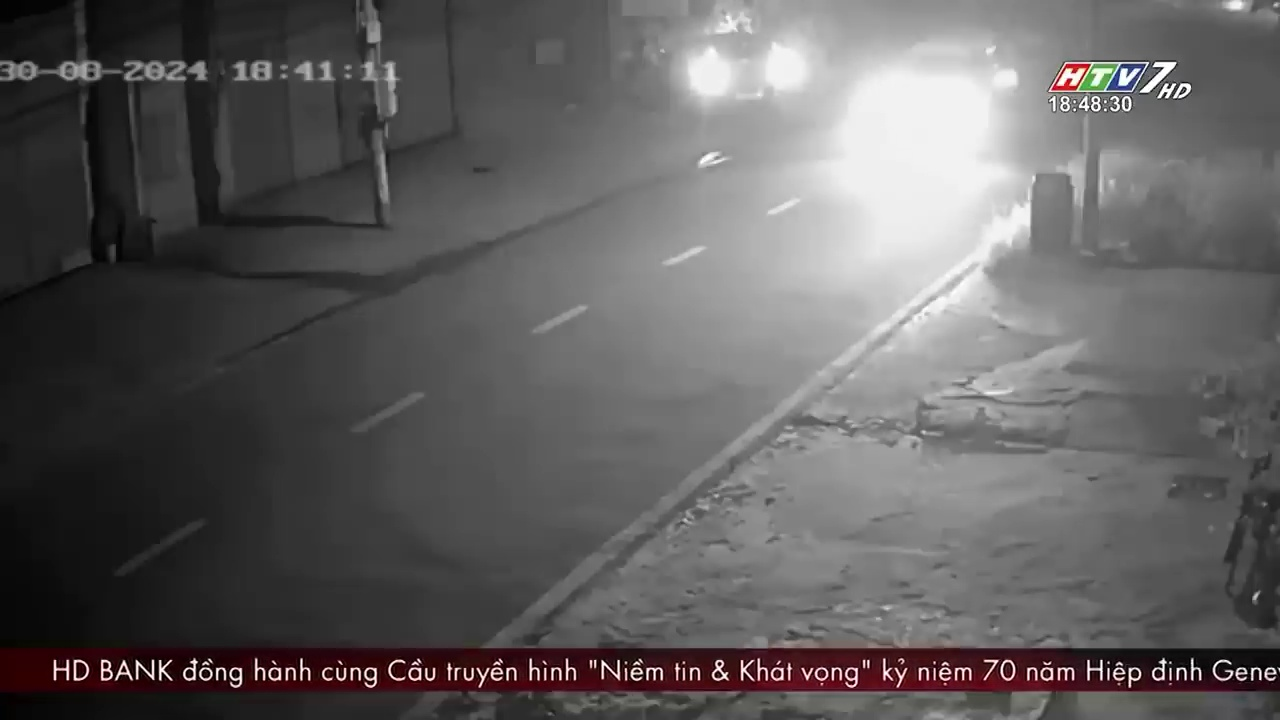 |
| **#03** | `0.3311` | L22_V031 | 22670 | 906.8s (15m 6s) | kf_559 | 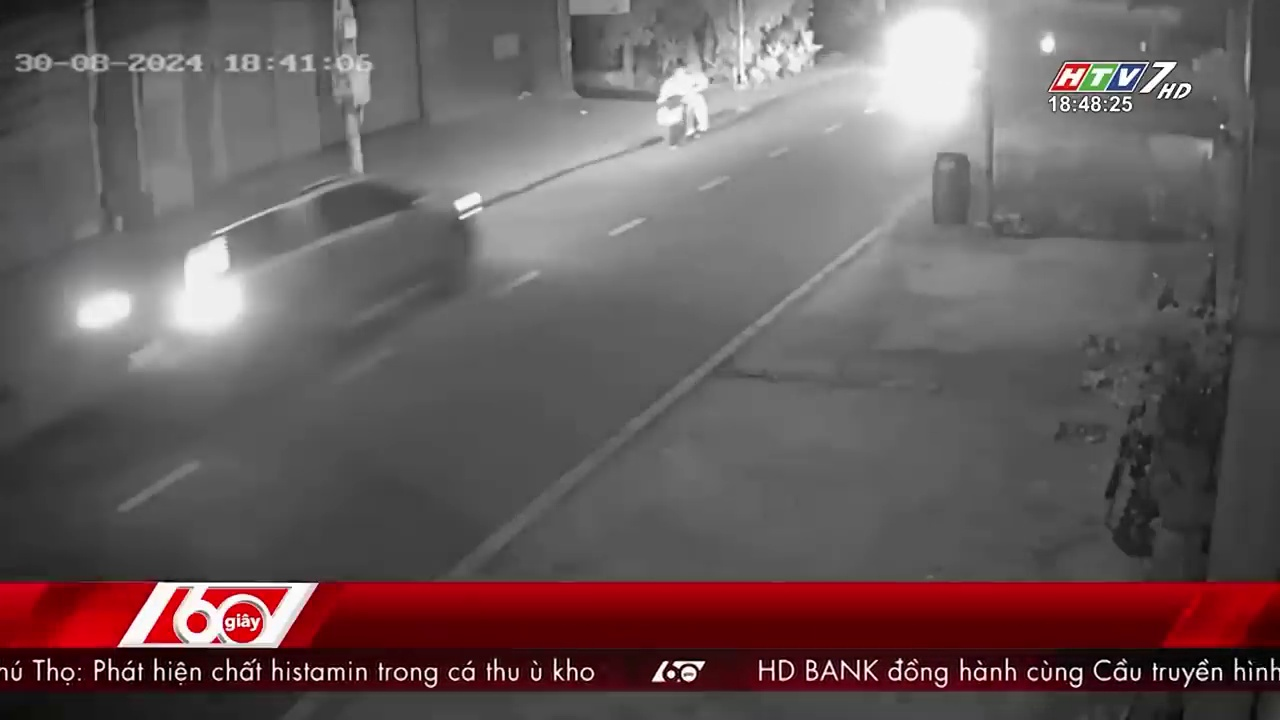 |
| **#04** | `0.3245` | L22_V031 | 23010 | 920.4s (15m 20s) | kf_563 | 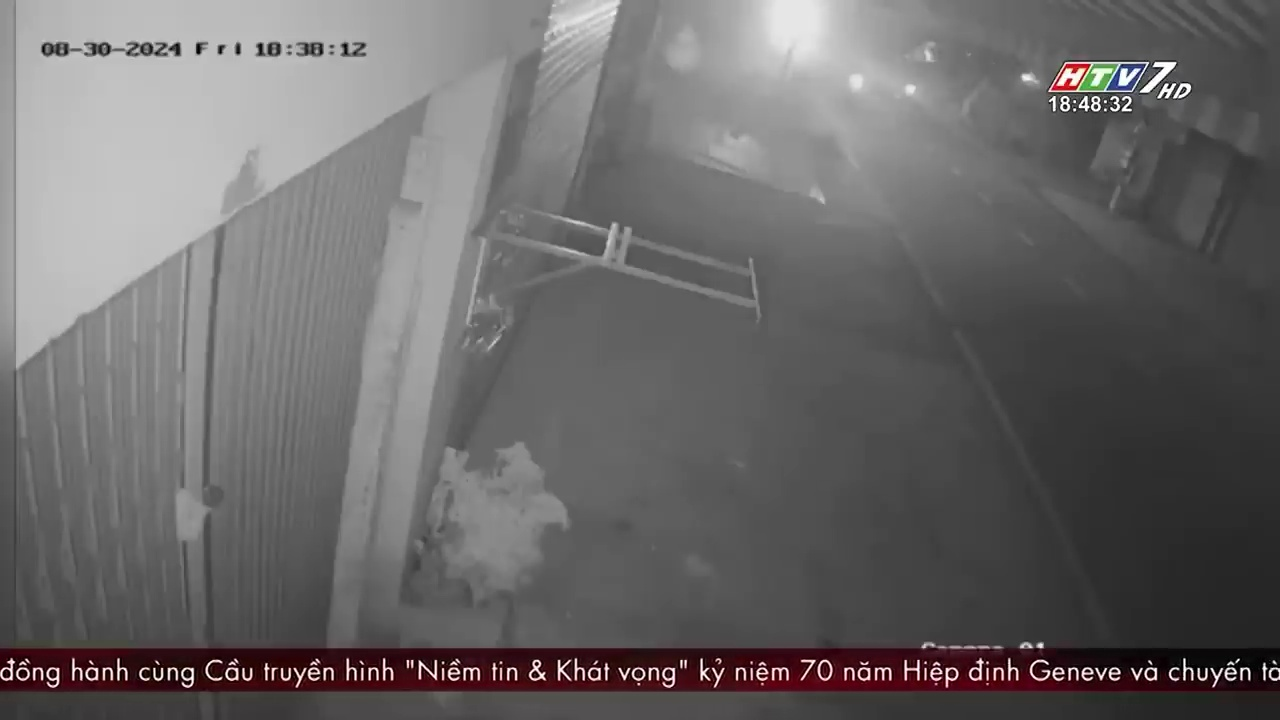 |
| **#05** | `0.3187` | L22_V031 | 23070 | 922.8s (15m 22s) | kf_564 | 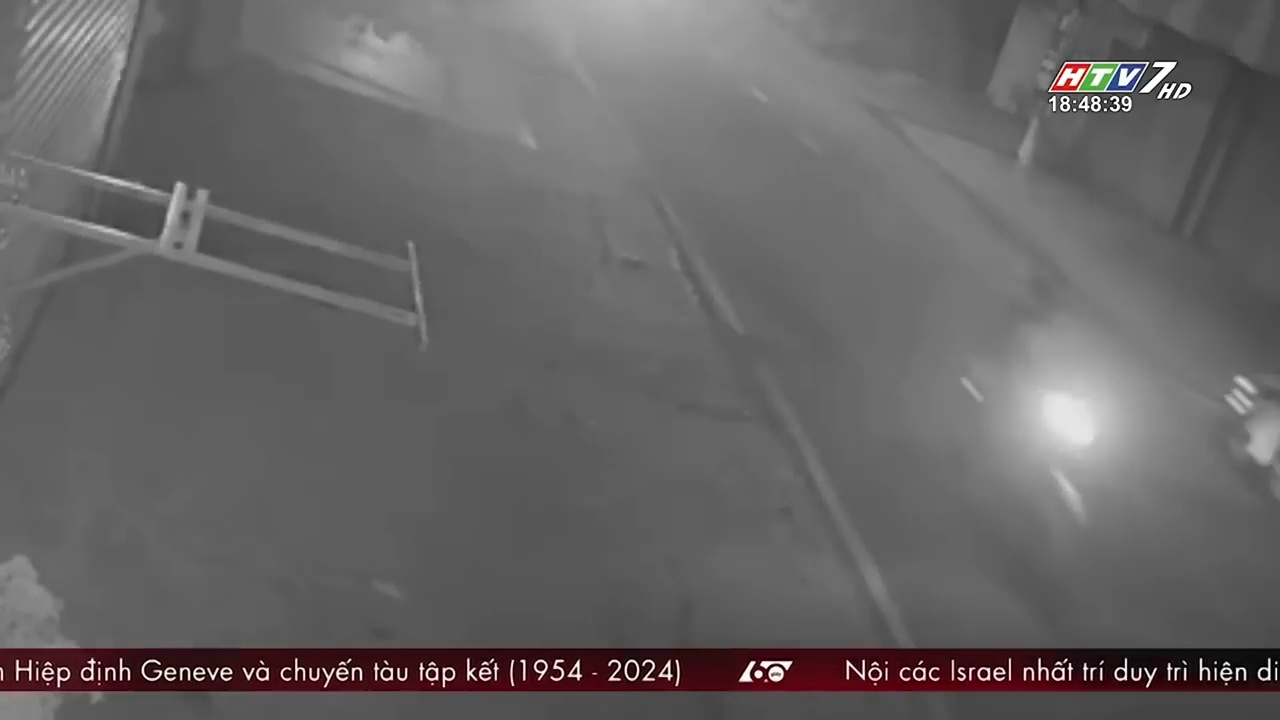 |
| **#06** | `0.3154` | L22_V023 | 24150 | 966.0s (16m 6s) | kf_563 | 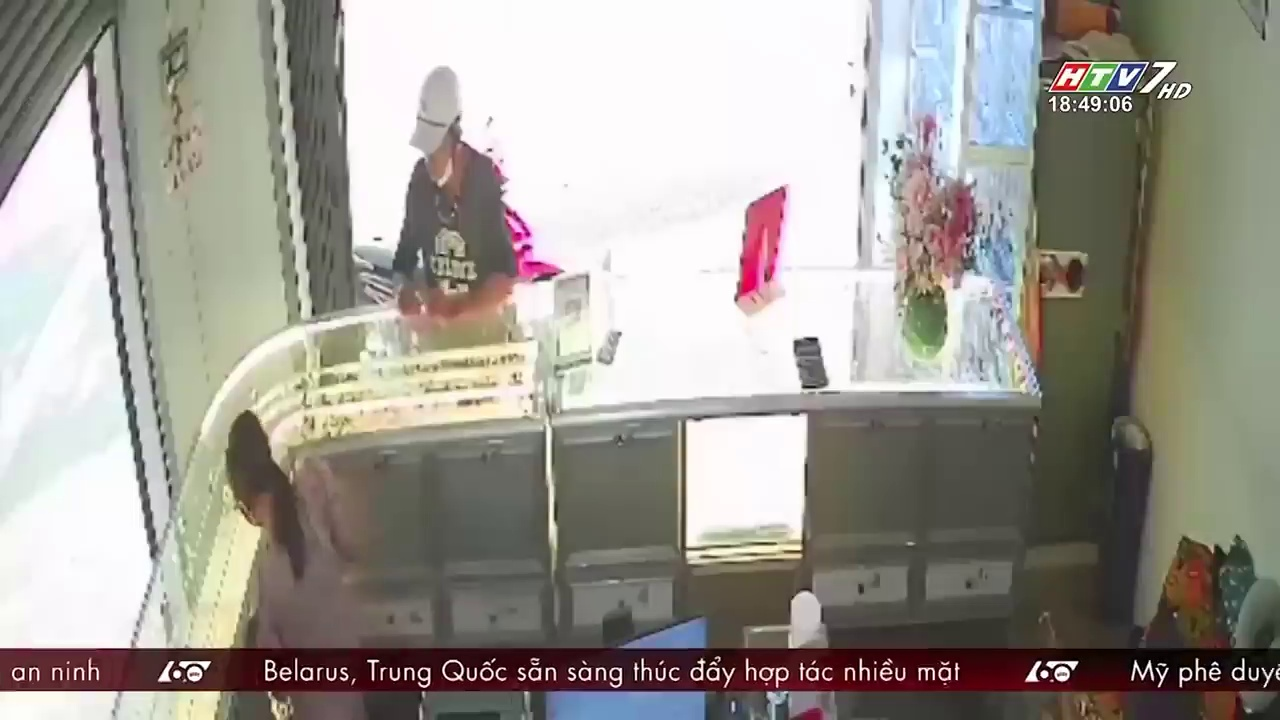 |
| **#07** | `0.3149` | L22_V031 | 22670 | 906.8s (15m 6s) | kf_558 | 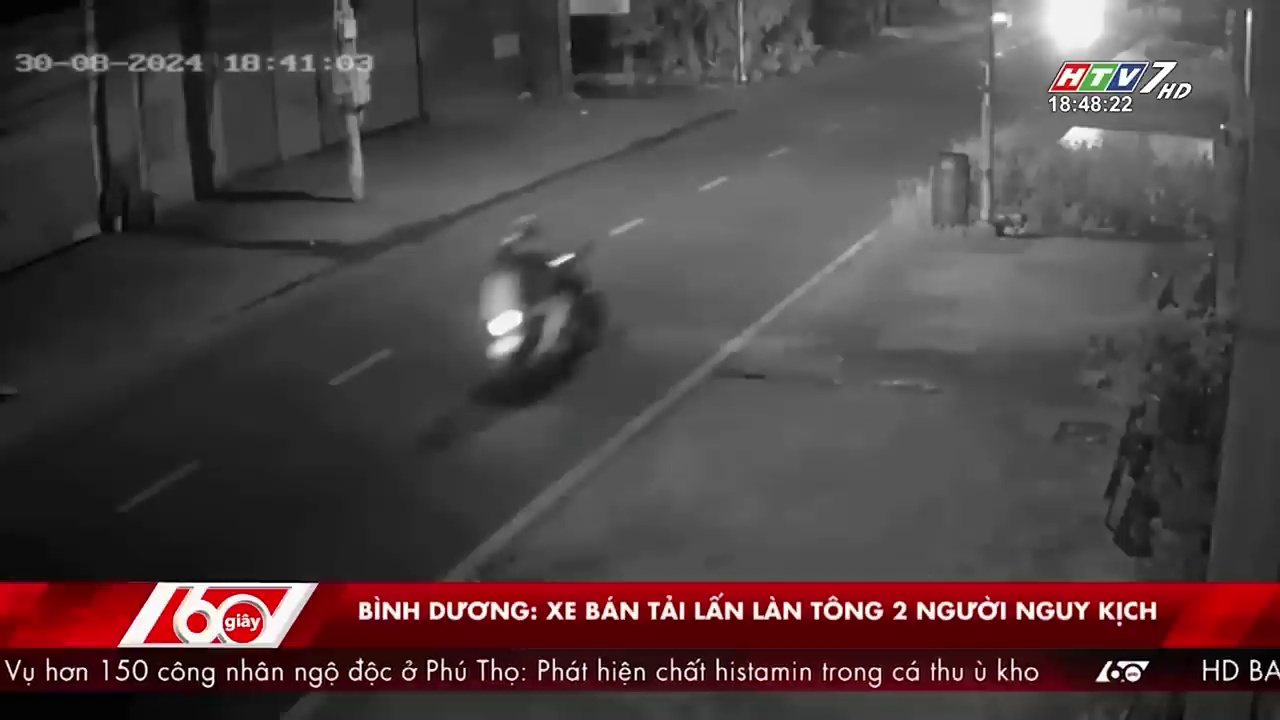 |
| **#08** | `0.3103` | L22_V031 | 22805 | 912.2s (15m 12s) | kf_561 | 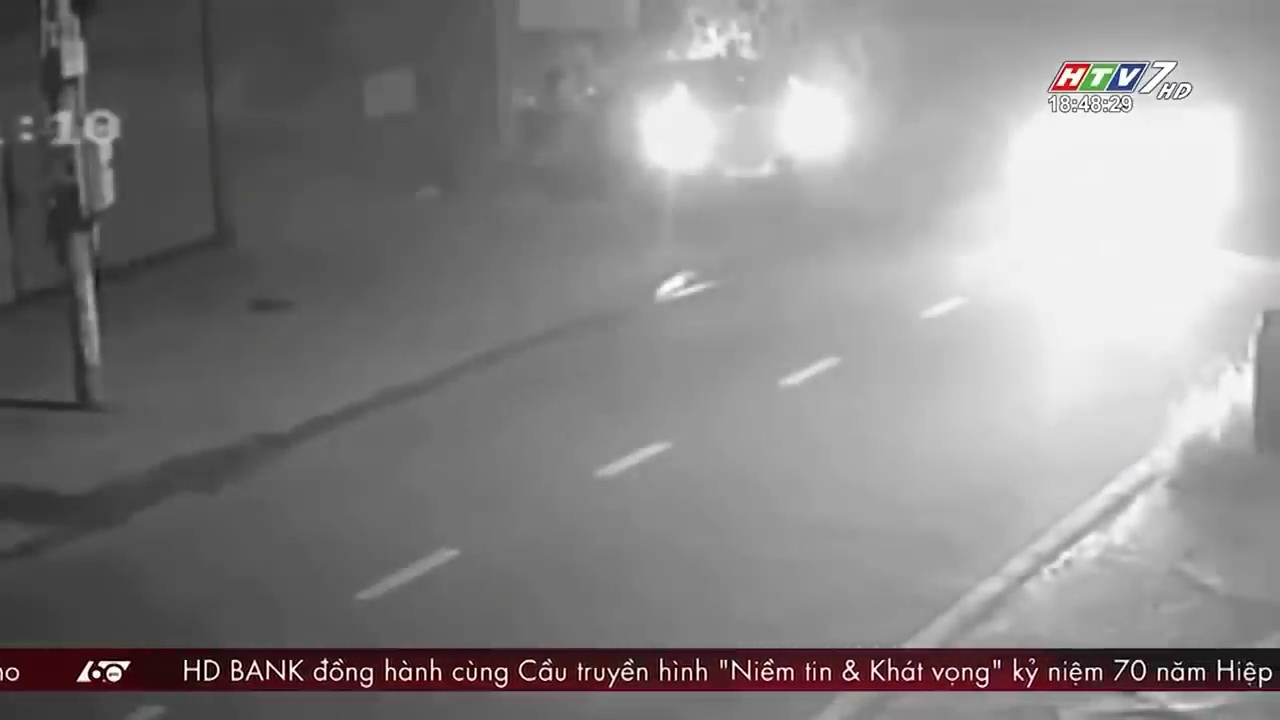 |
| **#09** | `0.3102` | L22_V031 | 22780 | 911.2s (15m 11s) | kf_560 | 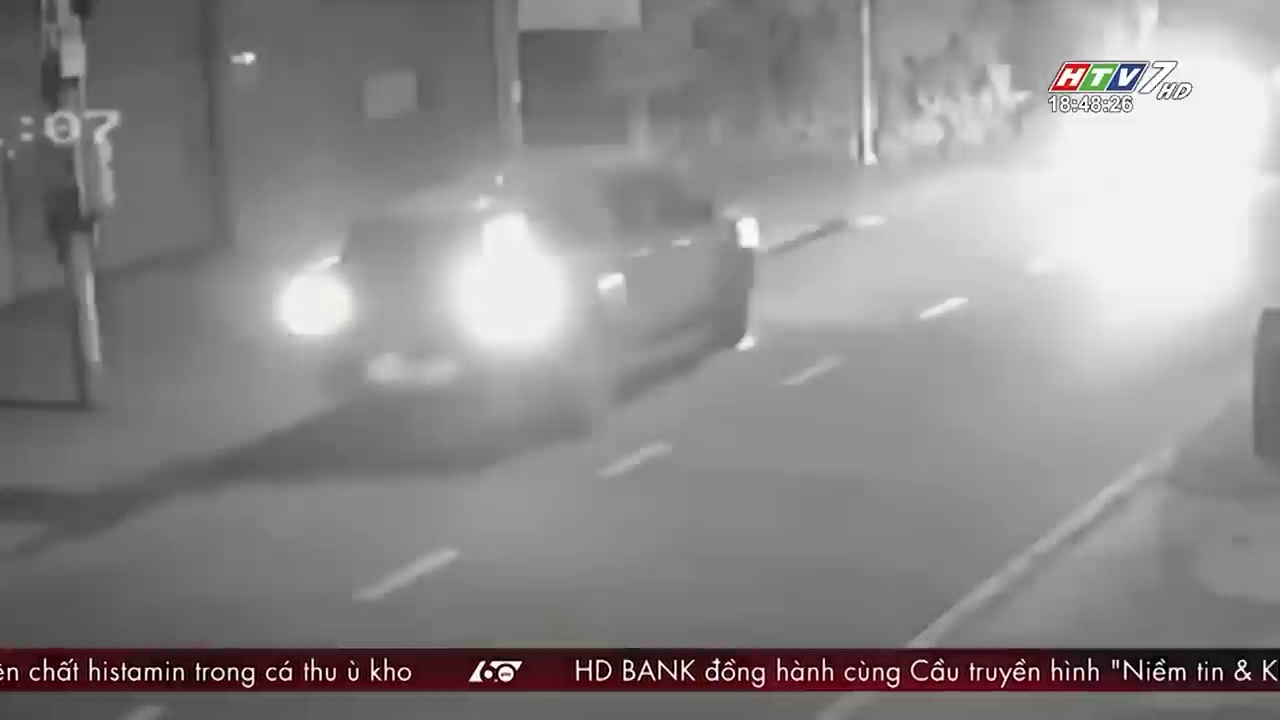 |
| **#10** | `0.3093` | L21_V010 | 18345 | 733.8s (12m 13s) | kf_523 | 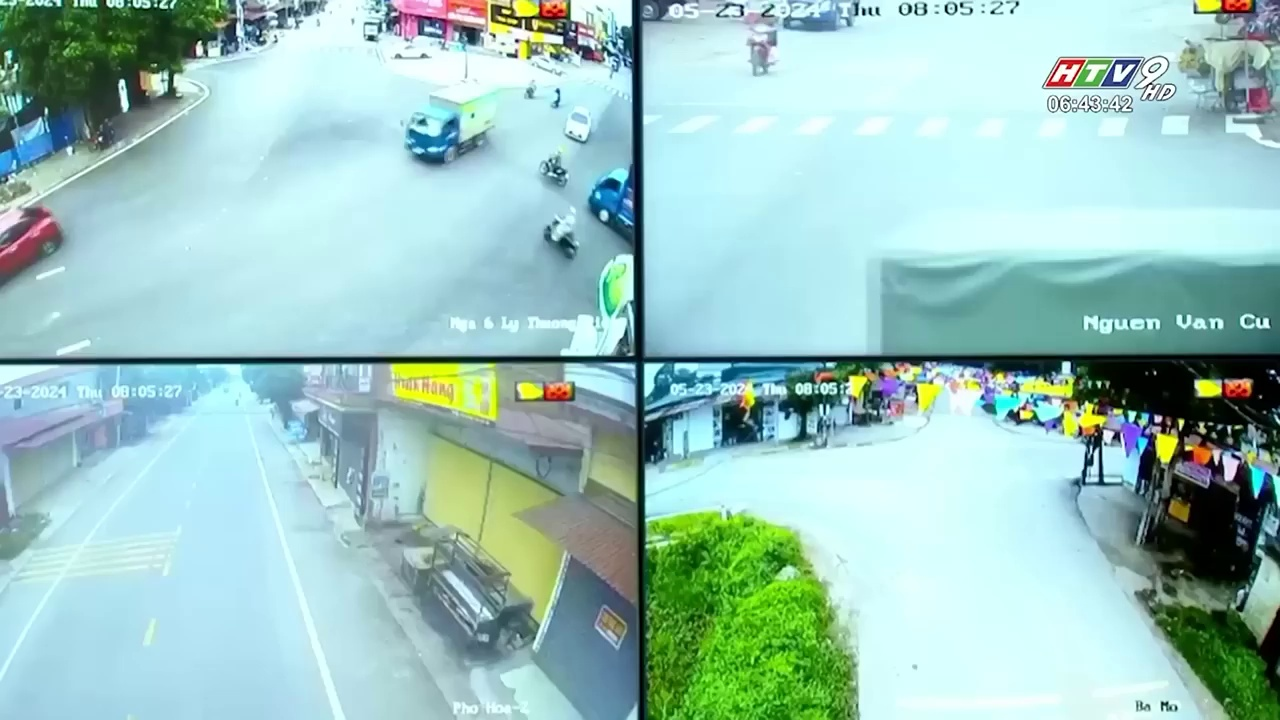 |


In [20]:
import sys
import os
import base64
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

# 1. Tự động tìm đường dẫn thư mục gốc để import module 'backend' không bị lỗi
current_dir = Path.cwd()
while not (current_dir / "backend").exists() and current_dir.parent != current_dir:
    current_dir = current_dir.parent
if str(current_dir) not in sys.path:
    sys.path.insert(0, str(current_dir))

from backend.embedding.clip_encoder import encode_text_raw
from backend.embedding.remote_index import search_remote

# 2. Đặt câu truy vấn tại đây
QUERY = "Black and white surveillance CCTV camera footage showing a street robbery"
TOP_K = 10

# 3. Mã hoá câu truy vấn thành Vector 512 chiều
query_vector = encode_text_raw(QUERY)

# 4. Gọi hàm search từ Qdrant
results = search_remote(query_vector=query_vector, top_k=TOP_K)

# 5. Hiển thị kết quả dạng bảng Markdown
markdown_str = f"### Kết quả truy vấn từ Qdrant Cloud với Query = `{QUERY}`:\n\n"
markdown_str += "| Rank | Score | Video ID | Frame ID | Thời điểm (s) | Clip ID | Ảnh Minh Hoạ |\n"
markdown_str += "| :---: | :---: | :---: | :---: | :---: | :---: | :---: |\n"

for idx, res in enumerate(results):
    rank = f"**#{idx+1:02d}**"
    score = f"`{res.get('score', 0.0):.4f}`"
    vid = res.get('video_id', '')
    fid = res.get('frame_id', '')
    
    # Ép kiểu float() an toàn để tránh lỗi TypeError khi chia
    pts = float(res.get('pts_time', 0.0))
    m = int(pts // 60)
    s = int(pts % 60)
    pts_str = f"{pts:.1f}s ({m}m {s}s)"
    
    cid = res.get('clip_id', '')
    
    # Đồng bộ đường dẫn tuyệt đối cho file ảnh
    path = str(res.get('path', ''))
    full_img_path = current_dir / path if not os.path.isabs(path) else Path(path)
    
    img_tag = "Không có ảnh"
    if path and full_img_path.exists():
        with open(full_img_path, "rb") as img_file:
            b64_string = base64.b64encode(img_file.read()).decode('utf-8')
            img_tag = f"<img src='data:image/jpeg;base64,{b64_string}' width='160' style='border-radius: 8px;' />"
    elif path:
        img_tag = f"Lỗi file ảnh: {path}"

    markdown_str += f"| {rank} | {score} | {vid} | {fid} | {pts_str} | {cid} | {img_tag} |\n"

display(Markdown(markdown_str))